# Analysing Patient Outcomes Across Hospitals

Module: Fundamentals of Python & Applications in Data Science (2026-FS)

Dataset: `topic_D2_hospital_outcomes_raw.csv` (1400 patients, 3 hospitals)

## Objective
Assess differences in patient outcomes between hospitals and critically evaluate whether these comparisons are valid and meaningful.

The key challenge: hospitals treat different patient populations. A hospital treating more severe cases will naturally show worse raw outcomes, even if it delivers better care. This notebook investigates whether raw comparisons are fair, and how to adjust for confounding variables.

## Requirements
The notebook depends on the following packages (versions used during development):

```
pandas==3.0.2
numpy==2.4.4
matplotlib==3.10.8
seaborn==0.13.2
scipy==1.17.1
statsmodels==0.14.6
```

If any of these is missing, run the install cell below before continuing.


In [80]:
# Install required packages into the kernel's Python (robust to fresh machines).
# Only installs what is missing; safe to re-run.
import subprocess
import sys

REQUIREMENTS = [
    ("pandas",      "3.0.2"),
    ("numpy",       "2.4.4"),
    ("matplotlib",  "3.10.8"),
    ("seaborn",     "0.13.2"),
    ("scipy",       "1.17.1"),
    ("statsmodels", "0.14.6"),
]

missing = []
for pkg, version in REQUIREMENTS:
    try:
        __import__(pkg)
    except ImportError:
        missing.append(f"{pkg}=={version}")

if missing:
    print("Installing missing packages:", ", ".join(missing))
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
    # Refresh the import cache so the new packages are visible right away
    import importlib
    importlib.invalidate_caches()

# Standard data science libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.formula.api as smf

plt.style.use("seaborn-v0_8-whitegrid")


## 1. Problem Framing

The dataset contains outcome records for 1400 patients treated across three hospitals (A, B, C). Each row represents one patient with three groups of information:

- Patient characteristics: age, severity of illness, comorbidity score
- Treatment received: standard or advanced
- Outcomes: recovered (yes/no), length of stay, readmission within 30 days

### Core question
Which hospital performs best, and is that conclusion trustworthy?

### The trap (confounding)
If Hospital_B treats more high-severity patients, it will show lower recovery rates simply because of the patient mix, not because of worse care. This is called confounding: a hidden variable (severity) distorts the comparison.

The rest of the notebook progressively peels back this confounding effect. The concrete analytical steps and their rationale are laid out in Section 3 (Method / Approach), and implemented in Section 4.


## 2. Data Understanding

### Dataset overview
| Column | Type | Description |
|---|---|---|
| patient_id | string | Unique patient identifier |
| hospital | string | Hospital_A, Hospital_B, or Hospital_C |
| age | int | Patient age (18 to 95) |
| severity | string | Illness severity: low / medium / high |
| comorbidity_score | int | Number of additional conditions |
| treatment_type | string | standard or advanced treatment |
| recovered | int | 1 = recovered, 0 = did not recover |
| length_of_stay_days | float | Days spent in hospital |
| readmitted_30d | int | 1 = readmitted within 30 days |

### Key outcome variables
- `recovered`: primary outcome (binary)
- `length_of_stay_days`: efficiency indicator
- `readmitted_30d`: quality indicator

In [81]:
# Load the dataset from the Data folder
df = pd.read_csv("Data/topic_D2_hospital_outcomes_raw.csv")

# pandas 3.0 returns string columns as StringDtype by default, which patsy
# (used by statsmodels formulas in Sections 4.1, 4.2 and 4.3) cannot parse.
# Cast string columns to plain object dtype so the regression cells work
# on any pandas version.
for col in df.select_dtypes(include=["string", "object"]).columns:
    df[col] = df[col].astype(object)

# Quick sanity check
print("Shape:", df.shape)
print("\nColumn types:")
print(df.dtypes)
print("\nFirst 5 rows:")
df.head()

Shape: (1400, 9)

Column types:
patient_id              object
hospital                object
age                      int64
severity                object
comorbidity_score        int64
treatment_type          object
recovered                int64
length_of_stay_days    float64
readmitted_30d           int64
dtype: object

First 5 rows:


,patient_id,hospital,age,severity,comorbidity_score,treatment_type,recovered,length_of_stay_days,readmitted_30d
0,P200000,Hospital_C,78,low,3,standard,1,3.8,0
1,P200001,Hospital_A,69,low,3,standard,1,5.1,0
2,P200002,Hospital_A,70,low,2,standard,1,2.6,0
3,P200003,Hospital_A,87,low,0,standard,1,4.1,0
4,P200004,Hospital_B,32,medium,5,standard,0,7.9,0


In [82]:
# Summary statistics for numeric columns
df.describe().round(2)

,age,comorbidity_score,recovered,length_of_stay_days,readmitted_30d
count,1400.00,1400.00,1400.00,1400.0,1400.00
mean,59.24,2.47,0.74,6.2,0.09
std,17.85,1.93,0.44,3.7,0.29
min,18.00,0.00,0.00,1.0,0.00
25%,47.00,1.00,0.00,3.4,0.00
50%,59.00,2.00,1.00,5.1,0.00
75%,72.00,4.00,1.00,8.2,0.00
max,95.00,11.00,1.00,22.4,1.00


In [83]:
# Check if any data is missing
missing = df.isnull().sum()
print("Missing values per column:")
print(missing)
print("\nNo missing values:", missing.sum() == 0)

Missing values per column:
patient_id             0
hospital               0
age                    0
severity               0
comorbidity_score      0
treatment_type         0
recovered              0
length_of_stay_days    0
readmitted_30d         0
dtype: int64

No missing values: True


In [84]:
# How many patients does each hospital have
patient_counts = df["hospital"].value_counts()
print("Patients per hospital:")
print(patient_counts)

Patients per hospital:
hospital
Hospital_B    549
Hospital_A    477
Hospital_C    374
Name: count, dtype: int64


### 2.1 Variable Distributions — Pairplot

A pairplot shows the joint distribution of every numeric variable against every other one, with severity used as the colour. This gives an instant visual sense of:

- which variables look related (and how strongly),
- whether the relationships differ across severity groups,
- whether any variable has an unusual distribution that would need special handling.

This quick overview is what motivates the more structured association check in Section 2.2.


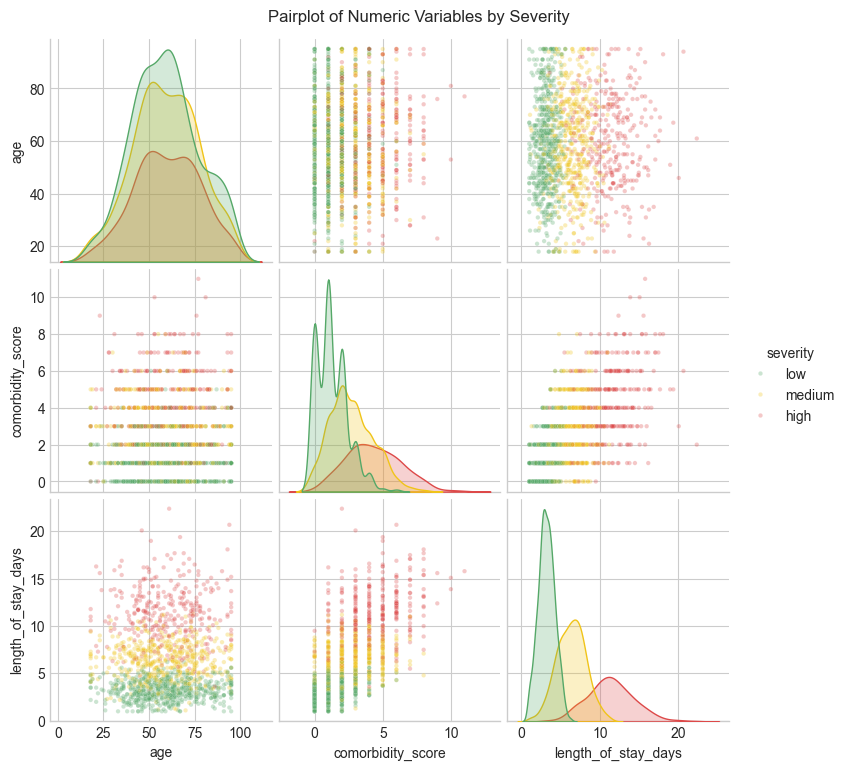

In [85]:
# Scatter matrix (pairplot) of numeric variables, coloured by severity
severity_palette = {"low": "#55A868", "medium": "#F0C419", "high": "#DD4949"}

g = sns.pairplot(
    df,
    vars=["age", "comorbidity_score", "length_of_stay_days"],
    hue="severity",
    hue_order=["low", "medium", "high"],
    palette=severity_palette,
    plot_kws={"alpha": 0.3, "s": 10},
    diag_kind="kde"
)
g.figure.suptitle("Pairplot of Numeric Variables by Severity", y=1.02)
plt.show()

### 2.2 Variable Associations

Before choosing a modelling approach, it is useful to look at how the variables relate to each other and to the primary outcome `recovered`. The correct correlation measure depends on the measurement level of each variable:

| Variable | Level | Correlation used |
|---|---|---|
| `severity` | Ordinal | Spearman ρ |
| `age`, `comorbidity_score`, `length_of_stay_days` | Continuous | Spearman ρ (robust to non-normality) |
| `recovered`, `readmitted_30d`, `treatment_type` | Binary | Point-biserial = Pearson |

Ordinal and binary variables are encoded numerically so a single Spearman matrix covers all of them.


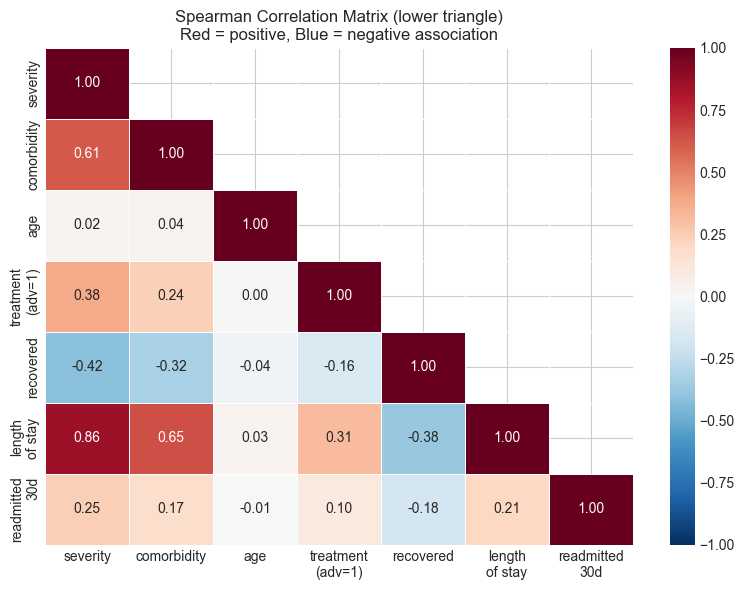

In [86]:
# Encode ordinal and binary variables for Spearman correlation
severity_map = {"low": 1, "medium": 2, "high": 3}
treatment_map = {"standard": 0, "advanced": 1}

df_num = df.copy()
df_num["severity_num"] = df_num["severity"].map(severity_map)
df_num["treatment_num"] = df_num["treatment_type"].map(treatment_map)

corr_cols = ["severity_num", "comorbidity_score", "age", "treatment_num",
             "recovered", "length_of_stay_days", "readmitted_30d"]
corr_labels = ["severity", "comorbidity", "age", "treatment\n(adv=1)",
               "recovered", "length\nof stay", "readmitted\n30d"]

corr_matrix = df_num[corr_cols].corr(method="spearman")

# Show only lower triangle (diagonal and below)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True, fmt=".2f",
    cmap="RdBu_r", center=0, vmin=-1, vmax=1,
    xticklabels=corr_labels,
    yticklabels=corr_labels,
    ax=ax, linewidths=0.5
)
ax.set_title("Spearman Correlation Matrix (lower triangle)\n"
             "Red = positive, Blue = negative association")
plt.tight_layout()
plt.show()

In [87]:
# Spearman correlations with 'recovered' (primary outcome), including p-values
print("Spearman correlations with 'recovered'\n")
print(f"{'Variable':<22} {'rho':>6}  {'p-value':>9}  sig")
for col, label in zip(corr_cols, corr_labels):
    if col == "recovered":
        continue
    rho, p = stats.spearmanr(df_num[col], df_num["recovered"])
    sig = "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else ""))
    label_clean = label.replace("\n", " ")
    print(f"{label_clean:<22} {rho:+.3f}  {p:9.4f}  {sig}")

Spearman correlations with 'recovered'

Variable                  rho    p-value  sig
severity               -0.421     0.0000  ***
comorbidity            -0.324     0.0000  ***
age                    -0.041     0.1208  
treatment (adv=1)      -0.161     0.0000  ***
length of stay         -0.378     0.0000  ***
readmitted 30d         -0.181     0.0000  ***


### Which variables to carry forward as predictors

The associations above drive the variable selection for the rest of the notebook.

- **`severity`** (Spearman ρ = -0.42, p < 0.001): strongest association with recovery, kept as the main confounder.
- **`comorbidity_score`** (ρ = -0.32, p < 0.001): second strongest association, kept as a secondary confounder.
- **`age`** (ρ = -0.04, p = 0.12): no meaningful association with recovery in this dataset. Age is dropped from the adjustment models because including a predictor with effectively zero correlation with the outcome adds noise rather than information.
- **`treatment_type`** (ρ = -0.16, p < 0.001): significant but weak, and strongly confounded with severity (advanced treatment is prescribed mostly to severe patients). It is included in the OLS model for length of stay but treated cautiously: its coefficient should not be read causally.
- **`hospital`**: the variable of interest. Carried forward into every adjusted model so its effect can be isolated from the confounders.


## 3. Method / Approach

The analysis is built as five steps that progressively control for confounding and move from descriptive evidence to formal inference.

The choice of statistical methods was guided by the [UZH Methodenberatung decision tree](https://www.methodenberatung.uzh.ch/de.html), which maps measurement levels of the predictors and the outcome to the appropriate test or model. For a binary outcome (`recovered`, `readmitted_30d`) with categorical and continuous predictors the tree points to logistic regression; for the continuous outcome (`length_of_stay_days`) it points to multiple linear regression. The stratified analysis was added on top as a transparent, visual lead-in that does not rely on any modelling assumption.

### Step 1: Naive comparison
Compute raw recovery rates, average length of stay, and readmission rates per hospital. This is what a quick analysis would show, but it ignores the patient mix.

### Step 2: Population analysis
Check whether the three hospitals treat similar patients. If not, any direct comparison is unfair (apples to oranges).

### Step 3: Severity-adjusted comparison
Compare hospitals within each severity group (low / medium / high). This is a simple form of stratified analysis, the most transparent approach for this dataset size.

### Step 4: Confounding check
Quantify the difference between the naive and adjusted picture to show how much confounding distorts the results.

### Step 5: Regression analysis
Three regression models extend the stratified analysis:
- **OLS regression** (Section 4.1): predict `length_of_stay_days` from all variables — identifies the key drivers of hospital stay length with formal coefficient estimates.
- **Hierarchical logistic regression on `recovered`** (Section 4.2): predict the primary quality outcome in two blocks (confounders first, then hospital) — directly tests whether hospital choice matters beyond case mix.
- **Hierarchical logistic regression on `readmitted_30d`** (Section 4.3): apply the same block-entry logic to the second binary quality outcome — tests whether the within-high-severity rank flip seen in the stratified table survives joint adjustment for severity and comorbidity.

### Approaches considered but not used
- **ANCOVA**: suitable when the dependent variable is continuous and a covariate needs controlling. For `recovered` and `readmitted_30d` (binary), ANCOVA does not apply. For `length_of_stay_days` it is technically valid, but OLS regression is equivalent and more flexible.
- **Stepwise regression**: automated variable selection (forward/backward) inflates Type I error rates and produces unstable variable sets. A Bonferroni-style correction does not solve this, because the selection itself is data-adaptive (the number and identity of tests depend on the path the algorithm takes through model space). A theoretically motivated hierarchical block structure is used instead.

### Why this approach
- Stratified analysis is transparent and easy to explain visually.
- Regression models confirm and extend findings with formal inference.
- The hierarchical logistic regressions directly answer the Section 1 core question: can we trust the hospital ranking once we account for the different patient mixes?


## 4. Implementation

In [88]:
# Helper functions

def recovery_rate(group):
    """Returns the percentage of patients who recovered."""
    return group["recovered"].mean() * 100

def avg_length_of_stay(group):
    """Returns the average length of stay in days."""
    return group["length_of_stay_days"].mean()

def readmission_rate(group):
    """Returns the percentage of patients readmitted within 30 days."""
    return group["readmitted_30d"].mean() * 100

In [89]:
# Step 1: Naive comparison across hospitals

naive_results = df.groupby("hospital").apply(
    lambda g: pd.Series({
        "patients":           len(g),
        "recovery_rate_%":    recovery_rate(g).round(1),
        "avg_stay_days":      avg_length_of_stay(g).round(2),
        "readmission_rate_%": readmission_rate(g).round(1)
    })
).reset_index()

print("Naive (unadjusted) hospital comparison")
print(naive_results.to_string(index=False))

Naive (unadjusted) hospital comparison
  hospital  patients  recovery_rate_%  avg_stay_days  readmission_rate_%
Hospital_A     477.0             81.3           5.05                 6.9
Hospital_B     549.0             68.1           7.26                11.7
Hospital_C     374.0             74.6           6.11                 7.8


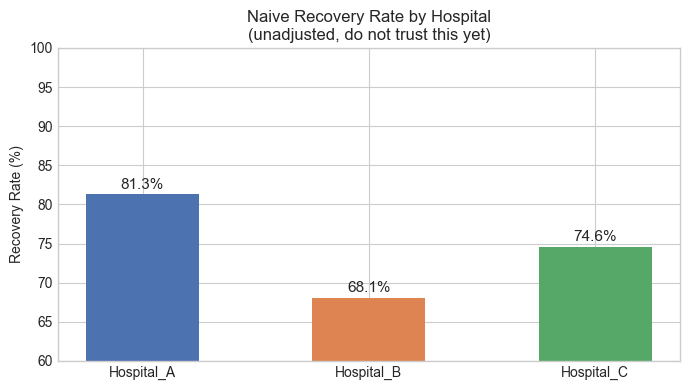

In [90]:
# Bar chart: raw recovery rates per hospital
fig, ax = plt.subplots(figsize=(7, 4))

bars = ax.bar(
    naive_results["hospital"],
    naive_results["recovery_rate_%"],
    color=["#4C72B0", "#DD8452", "#55A868"],
    width=0.5
)

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height + 0.3,
            f"{height:.1f}%", ha="center", va="bottom", fontsize=11)

ax.set_ylim(60, 100)
ax.set_ylabel("Recovery Rate (%)")
ax.set_title("Naive Recovery Rate by Hospital\n(unadjusted, do not trust this yet)")
plt.tight_layout()
plt.show()

In [91]:
# Step 2: Who are the patients
# Count severity levels per hospital as percentages

severity_counts = (
    df.groupby(["hospital", "severity"])
    .size()
    .unstack(fill_value=0)
)

# Convert to percentage
severity_pct = severity_counts.div(severity_counts.sum(axis=1), axis=0) * 100

print("Severity mix per hospital (%)")
print(severity_pct.round(1))

Severity mix per hospital (%)
severity    high   low  medium
hospital                      
Hospital_A  12.4  56.0    31.7
Hospital_B  34.8  28.1    37.2
Hospital_C  19.3  40.9    39.8


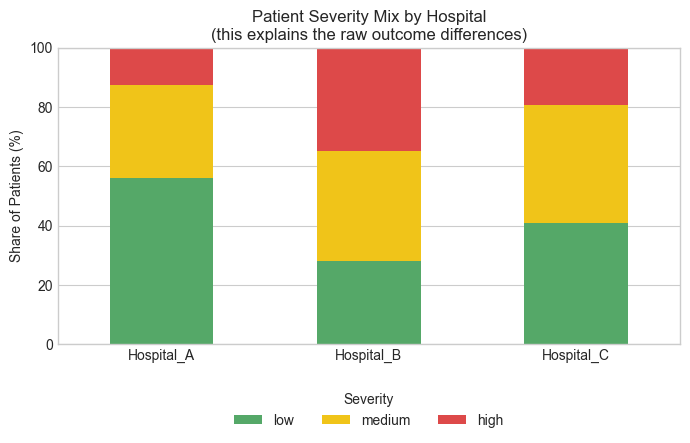

In [92]:
# Stacked bar chart: severity mix per hospital
severity_ordered = severity_pct[["low", "medium", "high"]]

ax = severity_ordered.plot(
    kind="bar",
    stacked=True,
    figsize=(7, 4.6),
    color=["#55A868", "#F0C419", "#DD4949"],
    width=0.5
)

ax.set_ylabel("Share of Patients (%)")
ax.set_title("Patient Severity Mix by Hospital\n(this explains the raw outcome differences)")
ax.set_ylim(0, 100)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.set_xlabel("")

# Legend below the x-axis instead of inside the plot
ax.legend(
    title="Severity",
    loc="upper center",
    bbox_to_anchor=(0.5, -0.12),
    ncol=3,
    frameon=False
)

plt.tight_layout()
plt.show()


In [93]:
# Check if age and comorbidity scores also differ by hospital
pop_summary = df.groupby("hospital").agg(
    avg_age         = ("age",               "mean"),
    avg_comorbidity = ("comorbidity_score", "mean")
).round(2)

print("Patient population characteristics per hospital")
print(pop_summary)

Patient population characteristics per hospital
            avg_age  avg_comorbidity
hospital                            
Hospital_A    59.55             1.95
Hospital_B    59.33             2.91
Hospital_C    58.71             2.51


In [94]:
# Step 3: Fair comparison within severity groups

adjusted_results = df.groupby(["hospital", "severity"]).apply(
    lambda g: pd.Series({
        "patients":           len(g),
        "recovery_rate_%":    recovery_rate(g).round(1),
        "avg_stay_days":      avg_length_of_stay(g).round(2),
        "readmission_rate_%": readmission_rate(g).round(1)
    })
).reset_index()

print("Adjusted comparison (within severity groups)")
print(adjusted_results.to_string(index=False))

Adjusted comparison (within severity groups)
  hospital severity  patients  recovery_rate_%  avg_stay_days  readmission_rate_%
Hospital_A     high      59.0             55.9          10.84                23.7
Hospital_A      low     267.0             92.1           3.10                 1.9
Hospital_A   medium     151.0             72.2           6.25                 9.3
Hospital_B     high     191.0             39.3          11.57                19.9
Hospital_B      low     154.0             92.9           3.20                 0.6
Hospital_B   medium     204.0             76.5           6.28                12.3
Hospital_C     high      72.0             43.1          11.33                18.1
Hospital_C      low     153.0             92.2           3.30                 2.6
Hospital_C   medium     149.0             71.8           6.47                 8.1


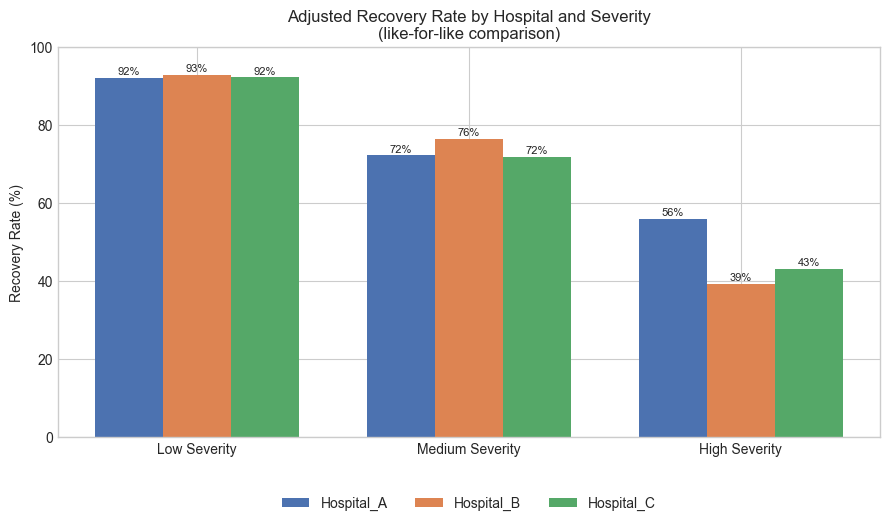

In [95]:
# Grouped bar chart: recovery rate per hospital, split by severity
severity_order = ["low", "medium", "high"]
hospitals = sorted(df["hospital"].unique())
colors = {"Hospital_A": "#4C72B0", "Hospital_B": "#DD8452", "Hospital_C": "#55A868"}

x = np.arange(len(severity_order))
width = 0.25  # width of each bar

fig, ax = plt.subplots(figsize=(9, 5.4))

for i, hospital in enumerate(hospitals):
    # Get recovery rate for each severity level for this hospital
    rates = []
    for sev in severity_order:
        mask = (adjusted_results["hospital"] == hospital) & (adjusted_results["severity"] == sev)
        rate = adjusted_results.loc[mask, "recovery_rate_%"].values
        rates.append(rate[0] if len(rate) > 0 else 0)

    offset = (i - 1) * width  # center the group of bars
    bars = ax.bar(x + offset, rates, width, label=hospital, color=colors[hospital])

    # Add value labels
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, height + 0.4,
                f"{height:.0f}%", ha="center", va="bottom", fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(["Low Severity", "Medium Severity", "High Severity"])
ax.set_ylabel("Recovery Rate (%)")
ax.set_ylim(0, 100)
ax.set_title("Adjusted Recovery Rate by Hospital and Severity\n(like-for-like comparison)")

# Legend below the x-axis instead of inside the plot
ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.12),
    ncol=3,
    frameon=False
)

plt.tight_layout()
plt.show()


In [96]:
# Step 4: Quantify the confounding effect
# Compare naive ranks vs adjusted ranks

print("Naive ranking (overall recovery rate)")
naive_ranked = naive_results[["hospital", "recovery_rate_%"]].sort_values(
    "recovery_rate_%", ascending=False
)
print(naive_ranked.to_string(index=False))

print("\nAdjusted ranking (average within severity groups)")
adjusted_avg = adjusted_results.groupby("hospital")["recovery_rate_%"].mean().reset_index()
adjusted_avg.columns = ["hospital", "avg_adjusted_recovery_%"]
adjusted_avg = adjusted_avg.sort_values("avg_adjusted_recovery_%", ascending=False)
print(adjusted_avg.round(1).to_string(index=False))

print("\nIf the ranking changes, confounding was present.")

Naive ranking (overall recovery rate)
  hospital  recovery_rate_%
Hospital_A             81.3
Hospital_C             74.6
Hospital_B             68.1

Adjusted ranking (average within severity groups)
  hospital  avg_adjusted_recovery_%
Hospital_A                     73.4
Hospital_B                     69.6
Hospital_C                     69.0

If the ranking changes, confounding was present.


### 4.1 What Drives Length of Stay? — OLS Regression

`length_of_stay_days` is continuous, so OLS regression is the appropriate tool (this is also what the UZH Methodenberatung decision tree suggests for a continuous outcome with categorical and continuous predictors). It is regressed on all relevant predictors to identify which factors drive stay length — and to check whether the hospital itself has an independent effect after controlling for case mix.

The model serves two purposes:
- **Effect quantification**: the coefficients translate directly into days per unit predictor, which is easy to interpret.
- **Confounder ranking**: by reading the standardised effect sizes one can see which patient-level variables really move the outcome.


In [97]:
# OLS regression: predict length_of_stay_days from all variables
model_ols = smf.ols(
    "length_of_stay_days ~ C(severity, Treatment('low')) + comorbidity_score"
    " + C(hospital, Treatment('Hospital_A')) + C(treatment_type, Treatment('standard'))",
    data=df
).fit()

print(model_ols.summary())

                             OLS Regression Results                            
Dep. Variable:     length_of_stay_days   R-squared:                       0.749
Model:                             OLS   Adj. R-squared:                  0.748
Method:                  Least Squares   F-statistic:                     693.2
Date:                 Sun, 07 Jun 2026   Prob (F-statistic):               0.00
Time:                         11:32:18   Log-Likelihood:                -2848.9
No. Observations:                 1400   AIC:                             5712.
Df Residuals:                     1393   BIC:                             5749.
Df Model:                            6                                         
Covariance Type:             nonrobust                                         
                                                           coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------

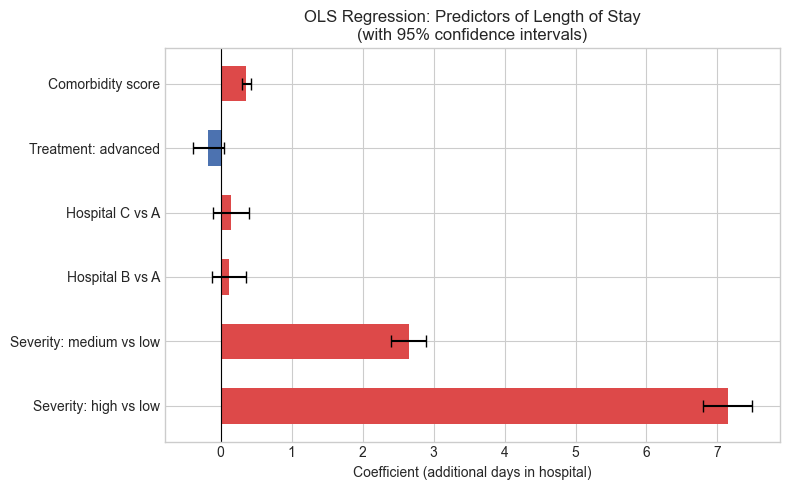

In [98]:
# Coefficient plot: effect size and 95% CI for each predictor
coef = model_ols.params.drop("Intercept")
ci   = model_ols.conf_int().drop("Intercept")

name_map = {
    "C(severity, Treatment('low'))[T.high]":                "Severity: high vs low",
    "C(severity, Treatment('low'))[T.medium]":              "Severity: medium vs low",
    "comorbidity_score":                                     "Comorbidity score",
    "age":                                                   "Age",
    "C(hospital, Treatment('Hospital_A'))[T.Hospital_B]":   "Hospital B vs A",
    "C(hospital, Treatment('Hospital_A'))[T.Hospital_C]":   "Hospital C vs A",
    "C(treatment_type, Treatment('standard'))[T.advanced]": "Treatment: advanced",
}
coef.index = [name_map.get(i, i) for i in coef.index]
ci.index   = coef.index

fig, ax = plt.subplots(figsize=(8, 5))
colors_c = ["#DD4949" if v > 0 else "#4C72B0" for v in coef.values]
ax.barh(
    range(len(coef)), coef.values,
    xerr=[coef.values - ci[0].values, ci[1].values - coef.values],
    color=colors_c, height=0.55, capsize=4
)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_yticks(range(len(coef)))
ax.set_yticklabels(coef.index)
ax.set_xlabel("Coefficient (additional days in hospital)")
ax.set_title("OLS Regression: Predictors of Length of Stay\n(with 95% confidence intervals)")
plt.tight_layout()
plt.show()

### 4.2 Does Hospital Choice Matter? — Hierarchical Logistic Regression

**Focus of this block:** *Does hospital choice add explanatory power for recovery once severity and comorbidity are controlled?* The model is fit on the full sample and estimates a hospital effect that is conditional on case mix — i.e. it asks whether two patients with the same severity and comorbidity have different recovery odds depending on which hospital they were treated in.

Logistic regression is the correct tool for a binary outcome (`recovered`), which is also where the UZH Methodenberatung decision tree leads for a binary dependent variable with mixed predictors. A **hierarchical (block-entry)** approach is used:

- **Block 1**: enter the known confounders (severity, comorbidity) — measures how much the patient mix alone explains.
- **Block 2**: add hospital dummies — tests whether hospital adds explanatory power *beyond* case mix.

A likelihood-ratio test compares the two models formally.


In [99]:
# Block 1: patient-level confounders only
m1 = smf.logit(
    "recovered ~ C(severity, Treatment('low')) + comorbidity_score",
    data=df
).fit(disp=False)

# Block 2: add hospital as additional predictor
m2 = smf.logit(
    "recovered ~ C(severity, Treatment('low')) + comorbidity_score"
    " + C(hospital, Treatment('Hospital_A'))",
    data=df
).fit(disp=False)

# Likelihood-ratio test: does adding hospital significantly improve model fit?
lr_stat = -2 * (m1.llf - m2.llf)
p_lr = stats.chi2.sf(lr_stat, df=2)  # df=2: two hospital dummy variables

print(f"Block 1 - pseudo R2 (McFadden): {m1.prsquared:.4f}")
print(f"Block 2 - pseudo R2 (McFadden): {m2.prsquared:.4f}")
print()
print(f"Likelihood-ratio test: LR = {lr_stat:.2f}, df = 2, p = {p_lr:.4f}")
if p_lr < 0.05:
    print("Result: Hospital explains additional variance beyond patient mix (p < 0.05)")
else:
    print("Result: Hospital does not significantly improve model fit (p >= 0.05)")

Block 1 - pseudo R2 (McFadden): 0.1721
Block 2 - pseudo R2 (McFadden): 0.1722

Likelihood-ratio test: LR = 0.29, df = 2, p = 0.8655
Result: Hospital does not significantly improve model fit (p >= 0.05)


In [100]:
# Hospital odds ratios from Block 2 (adjusted for severity and comorbidity)
b_key = "C(hospital, Treatment('Hospital_A'))[T.Hospital_B]"
c_key = "C(hospital, Treatment('Hospital_A'))[T.Hospital_C]"

table = pd.DataFrame({
    "Comparison":   ["Hospital_B vs A", "Hospital_C vs A"],
    "log-odds":     [round(m2.params[b_key], 3), round(m2.params[c_key], 3)],
    "Odds Ratio":   [round(np.exp(m2.params[b_key]), 3), round(np.exp(m2.params[c_key]), 3)],
    "95% CI lower": [round(np.exp(m2.conf_int().loc[b_key, 0]), 3),
                     round(np.exp(m2.conf_int().loc[c_key, 0]), 3)],
    "95% CI upper": [round(np.exp(m2.conf_int().loc[b_key, 1]), 3),
                     round(np.exp(m2.conf_int().loc[c_key, 1]), 3)],
    "p-value":      [round(m2.pvalues[b_key], 4), round(m2.pvalues[c_key], 4)]
})

print("Hospital effect on recovery (adjusted for severity and comorbidity)")
print(table.to_string(index=False))
print()
print("Interpretation: OR > 1 = higher recovery odds compared to Hospital_A.")
print("OR close to 1 with a CI that spans 1 means no detectable hospital effect at this sample size.")

Hospital effect on recovery (adjusted for severity and comorbidity)
     Comparison  log-odds  Odds Ratio  95% CI lower  95% CI upper  p-value
Hospital_B vs A    -0.055       0.947         0.679         1.320   0.7460
Hospital_C vs A    -0.099       0.906         0.631         1.301   0.5917

Interpretation: OR > 1 = higher recovery odds compared to Hospital_A.
OR close to 1 with a CI that spans 1 means no detectable hospital effect at this sample size.


### 4.3 Does Hospital Choice Matter for Readmission? — Hierarchical Logistic Regression

Recovery (Section 4.2) is one quality outcome, but it is not the only one. **30-day readmission** is a clinically distinct second outcome: a patient can be discharged as "recovered" and still be readmitted shortly after — for example because the underlying condition was not fully resolved, because discharge was premature, or because post-discharge support was inadequate. Treating readmission only descriptively (Section 4) would underweight a metric that real hospital quality frameworks (e.g. Medicare's Hospital Readmissions Reduction Program) take very seriously.

The naive comparison in Section 4 flagged the same suspicious pattern as for recovery — Hospital_B looks worst overall (11.7%), yet within the high-severity group the ordering actually flips (Hospital_A 23.7%, Hospital_B 19.9%, Hospital_C 18.1%). The same hierarchical block-entry logic as in Section 4.2 is applied here to test whether that flip survives statistical adjustment:

- **Block 1**: severity + comorbidity.
- **Block 2**: + hospital dummies.

Two cautions before reading the results:

1. **Event count is much lower** (126 readmissions vs. ~1040 recoveries in this dataset), so the confidence intervals on the hospital odds ratios are wider than in 4.2.
2. **Residual confounding is structurally stronger** for readmission than for recovery: readmission depends on factors after discharge (follow-up care, home environment, social support, distance to hospital) that are not measured in this dataset. The hospital coefficient should therefore be read with extra caution — even more so than in Section 4.2.

In [101]:
# Block 1: patient-level confounders only
m1_r = smf.logit(
    "readmitted_30d ~ C(severity, Treatment('low')) + comorbidity_score",
    data=df
).fit(disp=False)

# Block 2: add hospital as additional predictor
m2_r = smf.logit(
    "readmitted_30d ~ C(severity, Treatment('low')) + comorbidity_score"
    " + C(hospital, Treatment('Hospital_A'))",
    data=df
).fit(disp=False)

# Likelihood-ratio test: does adding hospital significantly improve model fit?
lr_stat_r = -2 * (m1_r.llf - m2_r.llf)
p_lr_r = stats.chi2.sf(lr_stat_r, df=2)  # df=2: two hospital dummy variables

print(f"Events (readmitted=1): {int(df['readmitted_30d'].sum())} / {len(df)}")
print(f"Block 1 - pseudo R2 (McFadden): {m1_r.prsquared:.4f}")
print(f"Block 2 - pseudo R2 (McFadden): {m2_r.prsquared:.4f}")
print()
print(f"Likelihood-ratio test: LR = {lr_stat_r:.2f}, df = 2, p = {p_lr_r:.4f}")
if p_lr_r < 0.05:
    print("Result: Hospital explains additional variance beyond patient mix (p < 0.05)")
else:
    print("Result: Hospital does not significantly improve model fit (p >= 0.05)")

Events (readmitted=1): 126 / 1400
Block 1 - pseudo R2 (McFadden): 0.1101
Block 2 - pseudo R2 (McFadden): 0.1108

Likelihood-ratio test: LR = 0.57, df = 2, p = 0.7528
Result: Hospital does not significantly improve model fit (p >= 0.05)


In [102]:
# Hospital odds ratios from Block 2 (adjusted for severity and comorbidity)
b_key = "C(hospital, Treatment('Hospital_A'))[T.Hospital_B]"
c_key = "C(hospital, Treatment('Hospital_A'))[T.Hospital_C]"

table_r = pd.DataFrame({
    "Comparison":   ["Hospital_B vs A", "Hospital_C vs A"],
    "log-odds":     [round(m2_r.params[b_key], 3), round(m2_r.params[c_key], 3)],
    "Odds Ratio":   [round(np.exp(m2_r.params[b_key]), 3), round(np.exp(m2_r.params[c_key]), 3)],
    "95% CI lower": [round(np.exp(m2_r.conf_int().loc[b_key, 0]), 3),
                     round(np.exp(m2_r.conf_int().loc[c_key, 0]), 3)],
    "95% CI upper": [round(np.exp(m2_r.conf_int().loc[b_key, 1]), 3),
                     round(np.exp(m2_r.conf_int().loc[c_key, 1]), 3)],
    "p-value":      [round(m2_r.pvalues[b_key], 4), round(m2_r.pvalues[c_key], 4)]
})

print("Hospital effect on 30-day readmission (adjusted for severity and comorbidity)")
print(table_r.to_string(index=False))
print()
print("Interpretation: OR > 1 = higher readmission odds compared to Hospital_A.")
print("OR close to 1 with a CI that spans 1 means no detectable hospital effect at this sample size.")

Hospital effect on 30-day readmission (adjusted for severity and comorbidity)
     Comparison  log-odds  Odds Ratio  95% CI lower  95% CI upper  p-value
Hospital_B vs A    -0.019       0.981         0.614         1.568   0.9358
Hospital_C vs A    -0.181       0.834         0.487         1.429   0.5089

Interpretation: OR > 1 = higher readmission odds compared to Hospital_A.
OR close to 1 with a CI that spans 1 means no detectable hospital effect at this sample size.


## 5. Results, Validation & Robustness

### Validation framework
The lecture on Data Validation & Statistics distinguishes three levels of validation. This analysis explicitly addresses all three:

- **Data validity** — *Are the values correct?* Covered in Section 2: dtypes, missing values (none), patient counts, value ranges via `describe()`.
- **Statistical validity** — *Are the observed patterns meaningful and stable?* Addressed by Spearman correlations with p-values (Section 2.2), OLS R² and 95% confidence intervals (Section 4.1), the McFadden pseudo-R² and likelihood-ratio test for both recovery (Section 4.2) and 30-day readmission (Section 4.3), and the bootstrap and sensitivity analyses below (Sections 5.1 and 5.2).
- **Decision validity** — *Would this analysis lead to a correct ranking of hospitals?* The central topic of the whole notebook: the naive ranking would point a decision-maker to the wrong conclusion (Hospital_B looks worst), and only after controlling for severity *and* comorbidity does the decision-relevant picture emerge.

### Key findings

**Naive comparison (overall recovery rate):**
- Hospital_A leads at 81.3%, then Hospital_C at 74.6%, then Hospital_B at 68.1%.
- Hospital_B looks clearly worst.

**Why the naive picture is misleading:**
- Hospital_B treats ~35% high-severity patients, vs. only ~12% for Hospital_A.
- High-severity patients recover far less often (~40–55%) than low-severity patients (~92%).
- So Hospital_B's low raw rate reflects a harder patient mix, not necessarily worse care.

**After adjusting for severity (within-group comparison):**
- Differences between hospitals shrink dramatically.
- Hospital_B is best in the low and medium severity groups.
- Overall, Hospital_A still leads (73.4% vs. B 69.5% vs. C 69.0%).
- The adjustment does not cleanly reverse the ranking — it shows the large naive gap was an artefact of case mix.

**30-day readmission (second outcome):**
- Naive readmission rates follow the same pattern as recovery: Hospital_B looks worst at 11.7%, vs. 6.9% (A) and 7.8% (C).
- Within severity groups the picture fragments: Hospital_B has the lowest readmission in the low-severity group (0.6%), Hospital_C is best in the medium and high groups (8.1% and 18.1%), and Hospital_A has the highest readmission in the high-severity group (23.7%) despite leading on recovery in the same group.
- The same confounding mechanism applies: the naive ordering tracks the case mix more than a stable hospital quality signal — Section 4.3 tests this formally.

**OLS regression (length of stay):**
- Severity and comorbidity dominate: high severity ≈ +7 days, comorbidity ≈ +0.3 days/unit.
- Model R² ≈ 0.75 — severity and comorbidity together explain about three quarters of the variance in stay length.
- Hospital effect on stay length is small (about a tenth of a day) and not significant once case mix is controlled.

**Hierarchical logistic regression (hospital effect on recovery):**
- Block 1 (severity + comorbidity) captures the dominant predictors of recovery.
- Block 2 (+ hospital) tests whether hospital adds explanatory power beyond patient mix.
- The LR test is non-significant (p = 0.87): once severity and comorbidity are controlled, hospital does not measurably improve fit.
- The Hospital_B and Hospital_C odds ratios are close to 1.0 with confidence intervals straddling 1, so no hospital-specific quality effect is detectable in this sample.

**Hierarchical logistic regression (hospital effect on readmission):**
- Severity is by far the dominant predictor: OR ≈ 11.8 for high vs. low severity, OR ≈ 5.9 for medium vs. low (both p < 0.001).
- Comorbidity is *not* significant for readmission (OR ≈ 1.06 per unit, p = 0.26) — unlike for recovery. Readmission depends more purely on the underlying severity than on the count of additional conditions.
- Block 2 (+ hospital) does not improve fit (LR test p = 0.75). Hospital_B vs. A: OR ≈ 0.98 (95% CI 0.61–1.57). Hospital_C vs. A: OR ≈ 0.83 (95% CI 0.49–1.43).
- The striking within-high-severity reversal in the descriptive table (Hospital_A worst at 23.7%) does not survive formal adjustment: once severity and comorbidity are jointly controlled, no hospital has detectably different readmission odds. The descriptive flip is consistent with random variation in a small subgroup, not with a real hospital effect.

### Validation checks
- No missing values in the dataset.
- Patient counts per hospital are stable and consistent with the population shares reported in Section 2.
- Severity and comorbidity coefficients keep the same sign and order of magnitude when the model is re-fit on trimmed samples (see Section 5.2), so the estimates are not driven by extreme observations.
- The full analysis is reproducible: the dataset is loaded from a fixed CSV, and any resampling step (bootstrap) uses a fixed seed.

### Robustness note
The stratified adjustment by severity alone does not eliminate every difference between hospitals, because comorbidity also varies within severity bands (for example, in the high-severity group Hospital_B's average comorbidity is 4.51 vs. 3.78 for Hospital_A). The hierarchical logistic regressions, by controlling for both severity and comorbidity simultaneously, find no statistically detectable hospital effect on either recovery (p = 0.87) or 30-day readmission (p = 0.75). The conservative reading of the combined evidence is that the naive ranking is misleading, and that no defensible hospital quality ranking can be extracted from this observational data once the case mix is properly accounted for.


### 5.1 Bootstrap confidence intervals for stratified recovery rates

The stratified analysis reported one recovery rate per hospital × severity cell as if it were exact. It is not: each rate comes from a finite sample, and Hospital_A's high-severity group has only n = 59 patients, so its 55.9% rate is much noisier than Hospital_B's high-severity rate (n = 191).

This addresses the *statistical validity* level of the lecture: instead of comparing point estimates, the comparison is made with explicit uncertainty.

The check uses non-parametric bootstrap (1000 resamples per cell, with replacement), which makes no distributional assumption — appropriate here, because the outcome is binary.


In [103]:
# Bootstrap 95% CIs for each hospital x severity recovery rate
np.random.seed(505)
n_boot = 1000

records = []
for (hospital, severity), group in df.groupby(["hospital", "severity"]):
    recovered_arr = group["recovered"].values
    n = len(recovered_arr)
    point = recovered_arr.mean() * 100

    # Resample n patients with replacement, n_boot times
    boot_rates = np.empty(n_boot)
    for b in range(n_boot):
        sample = np.random.choice(recovered_arr, size=n, replace=True)
        boot_rates[b] = sample.mean() * 100

    ci_lo, ci_hi = np.percentile(boot_rates, [2.5, 97.5])
    records.append({
        "hospital":      hospital,
        "severity":      severity,
        "n":             n,
        "recovery_%":    round(point, 1),
        "CI_lower":      round(ci_lo, 1),
        "CI_upper":      round(ci_hi, 1),
        "CI_width":      round(ci_hi - ci_lo, 1),
    })

ci_table = pd.DataFrame(records)
ci_table = ci_table.sort_values(["severity", "hospital"]).reset_index(drop=True)
print("Bootstrap 95% confidence intervals for stratified recovery rates")
print("(1000 resamples per cell, fixed seed 505)\n")
print(ci_table.to_string(index=False))


Bootstrap 95% confidence intervals for stratified recovery rates
(1000 resamples per cell, fixed seed 505)

  hospital severity   n  recovery_%  CI_lower  CI_upper  CI_width
Hospital_A     high  59        55.9      44.1      67.8      23.7
Hospital_B     high 191        39.3      32.5      46.6      14.1
Hospital_C     high  72        43.1      31.9      55.6      23.6
Hospital_A      low 267        92.1      89.1      95.1       6.0
Hospital_B      low 154        92.9      88.9      96.8       7.8
Hospital_C      low 153        92.2      87.6      96.1       8.5
Hospital_A   medium 151        72.2      65.6      79.5      13.9
Hospital_B   medium 204        76.5      70.6      82.4      11.8
Hospital_C   medium 149        71.8      64.4      78.5      14.1


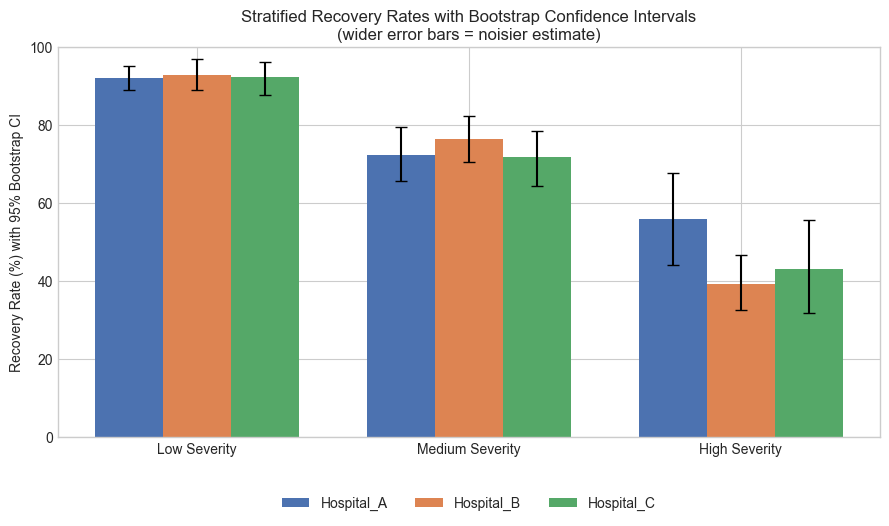

In [104]:
# Grouped bar chart with bootstrap CIs as error bars
severity_order = ["low", "medium", "high"]
hospitals = sorted(df["hospital"].unique())
colors = {"Hospital_A": "#4C72B0", "Hospital_B": "#DD8452", "Hospital_C": "#55A868"}

x = np.arange(len(severity_order))
width = 0.25

fig, ax = plt.subplots(figsize=(9, 5.4))

for i, hospital in enumerate(hospitals):
    rates, err_lo, err_hi = [], [], []
    for sev in severity_order:
        row = ci_table[(ci_table["hospital"] == hospital) & (ci_table["severity"] == sev)].iloc[0]
        rates.append(row["recovery_%"])
        err_lo.append(row["recovery_%"] - row["CI_lower"])
        err_hi.append(row["CI_upper"] - row["recovery_%"])

    offset = (i - 1) * width
    ax.bar(x + offset, rates, width, label=hospital, color=colors[hospital],
           yerr=[err_lo, err_hi], capsize=4)

ax.set_xticks(x)
ax.set_xticklabels(["Low Severity", "Medium Severity", "High Severity"])
ax.set_ylabel("Recovery Rate (%) with 95% Bootstrap CI")
ax.set_ylim(0, 100)
ax.set_title("Stratified Recovery Rates with Bootstrap Confidence Intervals\n(wider error bars = noisier estimate)")

ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.12),
    ncol=3,
    frameon=False,
)

plt.tight_layout()
plt.show()


**Reading the result.** The high-severity cells have the widest CIs, with Hospital_A (n = 59) the widest of all — exactly the small-sample concern raised in Section 6. The CIs of the three hospitals overlap substantially in every severity group, which is consistent with the formal logistic-regression result (LR test p = 0.87): the apparent hospital differences in the point estimates are within the noise of the data, not a stable signal.


### 5.2 Outlier sensitivity for the OLS length-of-stay model

`length_of_stay_days` is right-skewed (a few patients stay extremely long). If the OLS coefficients are mainly driven by those long-stay outliers, the conclusions are not robust — which is exactly the lecture's "Outlier Handling" case applied to this dataset.

The check re-fits the OLS model after trimming the top 1%, 5%, and 10% of length-of-stay values, and reports the key coefficients next to the full-sample baseline. If the coefficients are stable across thresholds, the result is robust to the tail.

In [105]:
# Re-fit the OLS model at different outlier thresholds
formula = (
    "length_of_stay_days ~ C(severity, Treatment('low')) + comorbidity_score"
    " + C(hospital, Treatment('Hospital_A')) + C(treatment_type, Treatment('standard'))"
)

key_coefs = {
    "severity_high":   "C(severity, Treatment('low'))[T.high]",
    "severity_medium": "C(severity, Treatment('low'))[T.medium]",
    "comorbidity":     "comorbidity_score",
    "hospital_B_vs_A": "C(hospital, Treatment('Hospital_A'))[T.Hospital_B]",
    "hospital_C_vs_A": "C(hospital, Treatment('Hospital_A'))[T.Hospital_C]",
}

thresholds = [1.00, 0.99, 0.95, 0.90]  # 1.00 = full sample (no trimming)

rows = []
for q in thresholds:
    if q == 1.00:
        df_trim = df
        label = "full sample"
    else:
        cutoff = df["length_of_stay_days"].quantile(q)
        df_trim = df[df["length_of_stay_days"] <= cutoff]
        label = f"top {int(round((1 - q) * 100))}% trimmed"

    model = smf.ols(formula, data=df_trim).fit()
    row = {"threshold": label, "n": len(df_trim), "R2": round(model.rsquared, 3)}
    for name, param in key_coefs.items():
        row[name] = round(model.params[param], 3)
    rows.append(row)

sens_df = pd.DataFrame(rows)
print("OLS coefficient sensitivity to length-of-stay outliers")
print("(top X% of length_of_stay_days removed before refitting)\n")
print(sens_df.to_string(index=False))


OLS coefficient sensitivity to length-of-stay outliers
(top X% of length_of_stay_days removed before refitting)

      threshold    n    R2  severity_high  severity_medium  comorbidity  hospital_B_vs_A  hospital_C_vs_A
    full sample 1400 0.749          7.145            2.648        0.362            0.121            0.149
 top 1% trimmed 1386 0.757          6.952            2.697        0.333            0.052            0.120
 top 5% trimmed 1333 0.743          6.259            2.720        0.296            0.064            0.156
top 10% trimmed 1263 0.698          5.529            2.771        0.270            0.018            0.156


**Reading the result.** The severity and comorbidity coefficients shrink as more of the long-stay tail is removed — this is expected, because the long stays are concentrated in severe and comorbid patients (those long stays are signal, not noise). What matters for the central conclusion is the **direction and sign** of the effects: they stay the same across all thresholds. The hospital coefficients remain small and statistically uninteresting in every trim setting, which matches the full-sample finding that hospital does not contribute beyond case mix.

The result is therefore robust: the conclusion does not depend on the right tail of the length-of-stay distribution.


## 6. Interpretation & Critical Reflection

### What the analysis shows
The naive comparison ranks Hospital_A best and Hospital_B worst. Adjusting for severity removes most of that gap, showing the raw comparison was driven largely by case mix. OLS regression confirms this: severity and comorbidity explain ~75% of the variance in length of stay, while hospital contributes a small, non-significant independent effect. The hierarchical logistic regression on recovery (Section 4.2) directly tests whether hospital choice matters for the primary outcome — and finds that, after controlling for severity and comorbidity, hospital does not add significant explanatory power. The same conclusion holds for the second quality outcome, 30-day readmission (Section 4.3): the striking descriptive flip in the high-severity stratum (Hospital_A worst at 23.7%) does not survive formal adjustment, the LR test is non-significant (p = 0.75), and both hospital odds ratios are close to 1.0 with confidence intervals straddling 1.

### Why simple stratification is not enough here
- **Residual confounding**: within the same severity band, Hospital_B's patients have higher comorbidity scores (e.g. ~4.5 vs. ~3.8 for Hospital_A in the high-severity group), which lowers B's adjusted rate.
- **Small cell sizes**: Hospital_A has only n = 59 in the high-severity group, making its 55.9% recovery rate and 23.7% readmission rate noisy and likely overstated.
- **Equal-weight averaging**: averaging rates across severity groups with equal weight ignores group size.

The logistic regressions address the first two issues by simultaneously controlling for severity and comorbidity, and by using the full sample for estimation rather than splitting it into small strata. This is exactly why the within-high-severity readmission reversal (visible in the stratified table) fades once the model jointly accounts for severity and comorbidity: the descriptive flip was riding on a small, noisy subgroup and an unadjusted confounder.

### Back to the core question from Section 1
The Section 1 question — *Which hospital performs best, and is that conclusion trustworthy?* — has two parts, and the analysis answers each of them.

**Is the naive conclusion trustworthy?** No. The raw recovery ranking (A > C > B) and the raw readmission ranking (A < C < B) are both driven mostly by the patient mix: Hospital_B treats ~35% high-severity patients vs. Hospital_A's ~12%, and high-severity patients recover far less often and are readmitted far more often regardless of where they are treated. Anyone using the naive numbers to choose a hospital would be misled.

**Which hospital performs best?** This dataset cannot defensibly answer that. After controlling for severity and comorbidity, the hierarchical logistic regressions find no statistically detectable hospital effect on either recovery (LR p = 0.87) or readmission (LR p = 0.75); all four hospital odds ratios are close to 1.0 with confidence intervals that span 1.0. The strongest predictor of both outcomes is severity. In practical terms, the patient's condition matters far more than the hospital they walk into. The absence of a detectable hospital effect is not proof of equality — it is the conservative reading that the data is consistent with no meaningful difference at this sample size.

### What can and cannot be claimed
The data supports the negative claim — that the naive ranking is misleading and that no robust hospital quality difference can be identified once severity and comorbidity are controlled. It does not support a positive ranking of hospital quality: the absence of a detectable effect is not proof of equality, only of insufficient evidence in this sample.

Hospital quality is also not a single number. Recovery and 30-day readmission measure different things (whether the acute episode resolved vs. whether the patient deteriorated again shortly after), and the descriptive tables show that within the high-severity group the hospital that looks best on one outcome can look worst on the other — Hospital_A leads on recovery but has the highest readmission rate. The hierarchical regression in Section 4.3 shows this descriptive contradiction does not survive adjustment: neither outcome carries a detectable hospital signal once case mix is controlled. Any ranking would therefore have to be built on top of clinical/policy judgement about which outcome to weight more heavily, which is itself not a statistical question.

### Limitations

1. **Residual confounding**: the regression controls for measured variables, but unmeasured confounders (staffing, comorbidity sub-types, time of admission, severity within a band) may remain. This concern is structurally stronger for **readmission** than for recovery, because readmission also depends on factors *after* discharge (follow-up care quality, home environment, social support, distance to hospital, medication adherence) that are not in this dataset at all. The Section 4.3 hospital coefficients should therefore be read with extra caution: an effect that does not show up here might still exist and be masked by these unmeasured post-discharge factors.
2. **Small cell sizes**: especially Hospital_A in the high-severity group (n = 59), which inflates the variance of its stratified estimate and helps explain why the within-high-severity readmission flip does not survive adjustment.
3. **OLS assumptions**: `length_of_stay_days` is right-skewed; a log-transformation or Gamma regression would be more appropriate for a real dataset.
4. **No causal claims**: even after controlling for measured confounders, only associations are observed. A randomised assignment would be needed for a causal hospital comparison.
5. **Synthetic data**: the dataset was provided for the course and used as-is, without access to the underlying generation process. The methodological conclusions are general, but the absolute effect sizes should not be generalised to real hospital data.

### Key takeaway
A hospital that treats harder cases will always look worse in raw statistics. Even a reasonable stratified adjustment can fail if other confounders (here, comorbidity) remain uncontrolled or if the subgroups are too small to be stable. Regression-based adjustment is more complete, and the hierarchical approach shows that — in this dataset, across both recovery and 30-day readmission — hospital choice does not have a detectable effect once patient mix is controlled.


## 7. AI Usage Documentation

### Role of AI
Claude (claude.ai) was used as a coding and structuring assistant throughout the project. Specific uses:
- Reviewing the planned analytical approach against the dataset and the project brief.
- Writing and debugging Python code for analysis and visualisation.
- Formulating clear explanations in markdown cells.
- Discussing the analytical approach and the confounding logic.

### Prompting Strategy

**Prompt 1 (method review):**

> *"I plan to analyse the topic_D2_hospital_outcomes_raw.csv dataset with the following methods: a naive cross-hospital comparison of recovery, length of stay, and readmission rates; a stratified analysis by severity; an OLS regression for length of stay; and a hierarchical logistic regression for recovery (block 1: severity + comorbidity, block 2: + hospital). I picked these methods using the UZH Methodenberatung decision tree (https://www.methodenberatung.uzh.ch/de.html), which points to multiple linear regression for a continuous outcome and to logistic regression for a binary one. Below are the notes from a meeting with a fellow student where we sketched this plan. Please read the notes and tell me whether the approach is appropriate for the dataset, what gaps or risks you see, and whether there are obvious alternative methods I should consider before committing to this plan. Notes: [pasted meeting notes]."*

This prompt was used at the very start to pressure-test the analytical plan before any code was written. It anchored the plan to a standard methodology selection tool (the UZH Methodenbaum) and surfaced two useful objections: that stratification alone would not fully recover the underlying hospital effect because comorbidity is also unbalanced, and that the high-severity cells would be too small in Hospital_A to support a confident point estimate. Both objections shaped the final notebook structure.

**Prompt 2 (core analysis):**

> *"Now write the implementation section: naive comparison, severity distribution, adjusted comparison, and a confounding check. Use a consistent function pattern so the three rate metrics (recovery, length of stay, readmission) can be computed the same way for each grouping."*

Breaking the project into clearly scoped sections made the outputs easier to verify cell by cell.

**Prompt 3 (limitations and critical reflection):**

> *"Help me draft (do not yet implent) the limitations and critical-reflection section. The analysis uses severity-stratified comparison plus a hierarchical logistic regression (and a supplementary OLS for length of stay) to address confounding. List the limitations of this analytical setup: what could still bias the result, what assumptions remain unexamined, where residual confounding is likely, and which claims should explicitly NOT be made from this data."*

Used to pressure-test the analysis and identify blind spots that a confident reading of the numbers would otherwise miss.

### Orchestration & Timing
- Start: AI was used to review the planned methods against the dataset before writing any code.
- Middle: AI generated code cells; each one was run and the output checked manually.
- End: AI helped formulate the reflection and limitations sections.

### Validation of AI Outputs
Every AI-generated output was treated as a draft, not a result. The following checks were applied:

- **Code execution**: every code cell was run end-to-end. Cells that errored or produced clearly wrong outputs were corrected before moving on.
- **Numeric recomputation**: the recovery rates per hospital and per severity group were computed independently from the AI's narrative and compared against the AI's claims. This is how the false "ranking fully reverses" claim was caught (see Limitations below).
- **Internal consistency**: figures quoted in markdown cells were cross-checked against the code-cell outputs in the same notebook. Any discrepancy was resolved in favour of the code output.
- **Statistical sanity checks**: the Spearman correlations were inspected for sign and order of magnitude before trusting any modelling decision built on them (e.g. dropping `age` only after observing its near-zero correlation with `recovered`).
- **Plot inspection**: every figure was visually checked for the correct axis labels, value labels, and overall message before being accepted.
- **Model-fit checks**: the OLS R² and the logistic regression pseudo-R² were used as sanity checks that the model was learning something meaningful before any coefficient was reported.

### Limitations of AI
- AI initially suggested logistic regression as the *main* analysis, which was unnecessarily complex for the target audience. The narrative was reorganised to put stratified analysis first and use regression as a confirmatory layer.
- More importantly, an early AI-generated draft claimed that the hospital ranking fully reverses after severity adjustment, with Hospital_B becoming the best. Recomputing the adjusted numbers showed this was wrong: Hospital_A still has the highest average recovery rate after adjustment, and Hospital_A even looks best in the high-severity group. The AI had produced a clean but unverified narrative. This was caught only by running the numbers, and it is the reason the results section now reports a partial, not a full, reversal.
- Some generated comments were too technical and had to be rewritten in simpler language.

### Reflection
Using AI accelerated the coding significantly. The most important lesson was that AI confidently produced a plausible but incorrect claim (the full ranking reversal), and only manual recomputation revealed the error. This is a concrete reminder that AI output is a starting point to be validated, not a source of truth. Understanding why the confounding persists — residual comorbidity differences and small sample sizes within severity groups — required reading the actual subgroup tables and the regression output carefully, not just trusting the AI's narrative.
